# Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer



## Original Linear Regression Model Attempt

In [2]:
# Load the transformed dataset
df_popularity0 = pd.read_csv('tracks2026.csv')
# These two decisions are explained in EDA and Data_Preparation
df_popularity0 = df_popularity0.dropna() 
df_popularity0 = df_popularity0.drop(columns = ["track_id"])

In [3]:
target = 'popularity'
X0 = df_popularity0.drop(columns=[target])
y0 = df_popularity0[target]

In [4]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = X0.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df_popularity0.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df_popularity0[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df_popularity0[col].min() >= 0]
# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
# Scale key and time_signature columns, as they have different scale than others
key_timesignature_cols = ["key", "time_signature"]
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
minmax_pipeline = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', MinMaxScaler())
])
# Do OneHotEncoding here to avoid test set containing information about the track-genre categories in training set. 
# If unknown value, ignore
onehotencode_pipeline = Pipeline(steps = [
    ("onehotencode", OneHotEncoder(handle_unknown='ignore'))
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
        ("onehotencode", onehotencode_pipeline, ["track_genre"] )
    ],
    remainder='passthrough'
)
print(no_outlier_cols)
print(outlier_cols_neg)
print(outlier_cols_pos)
print(key_timesignature_cols)



['valence', 'acousticness']
['loudness']
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
['key', 'time_signature']


In [5]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

# Setting a CV score
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

# Scoring variable
scoring = {
    "neg_MSE": "neg_mean_squared_error",
    "neg_RMSE": "neg_root_mean_squared_error",
    "neg_MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

# Split the data (80% training, 20% testing)
X_train0, X_test0, y_train0, y_test0 = train_test_split(X0, y0, test_size=0.2, random_state=42)

# Linear Regression Pipeline
pipe0 = Pipeline(steps = [('preprocess', preprocess_pipeline),
                         ('reduce_dim', PCA(iterated_power=7)),
                        ('regressor', LinearRegression())
                         ]
                         )


In [6]:
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE

# Setting a smaller amount of alternative values

N_FEATURES_OPTIONS = [2, 6, 11, 15, 19]
FIT_INTERCEPT_OPTIONS = [False, True]

param_grid = [
    {
        'reduce_dim': [PCA(iterated_power=7)],
        'reduce_dim__n_components': N_FEATURES_OPTIONS,
        'regressor__fit_intercept': FIT_INTERCEPT_OPTIONS
    },
    {
        'reduce_dim': [RFE(svm.SVR(kernel='linear', gamma='auto')),RFE(LinearRegression())],
        'reduce_dim__n_features_to_select': N_FEATURES_OPTIONS,
        'regressor__fit_intercept': FIT_INTERCEPT_OPTIONS
    }  
]


In [7]:
from sklearn import set_config

# Display pipeline in a more visual format
set_config(display='diagram')
pipe0

,steps,"[('preprocess', ...), ('reduce_dim', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('no_outliers', ...), ('outliers_neg', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
from sklearn.model_selection import GridSearchCV


lr_search0 = GridSearchCV(
    pipe0, 
    param_grid,
    scoring=scoring,    
    n_jobs=-1,
    cv=cv10,
    refit="R2",
    return_train_score=False)
# Initialize and train the Linear Regression model
lr_search0.fit(X_train0, y_train0)

print(f"Best parameters: {lr_search0.best_params_}")
print(f"Best R2 score: {lr_search0.best_score_:.4f}")

Best parameters: {'reduce_dim': RFE(estimator=LinearRegression()), 'reduce_dim__n_features_to_select': 11, 'regressor__fit_intercept': True}
Best R2 score: 0.0139


# SAM
I am having issues with feature importance, I may have to leave this to you I am sorry

In [9]:
# # Inspecting Feature Importance (Coefficients)
# coefficients = pd.DataFrame({'Feature': X0.columns, 'Coefficient': lr_search.coef_})
# coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
# print("\n--- Feature Coefficients (Influence on Popularity) ---")
# print(coefficients)

The R2 score is very low on this linear regression model, and looking at the graph we can see that there are a lot of zeros in the data set, a possibility could be that removing the zeros could improve the R2 score of the new linear regression model

## Looking at why the R2 could be so low

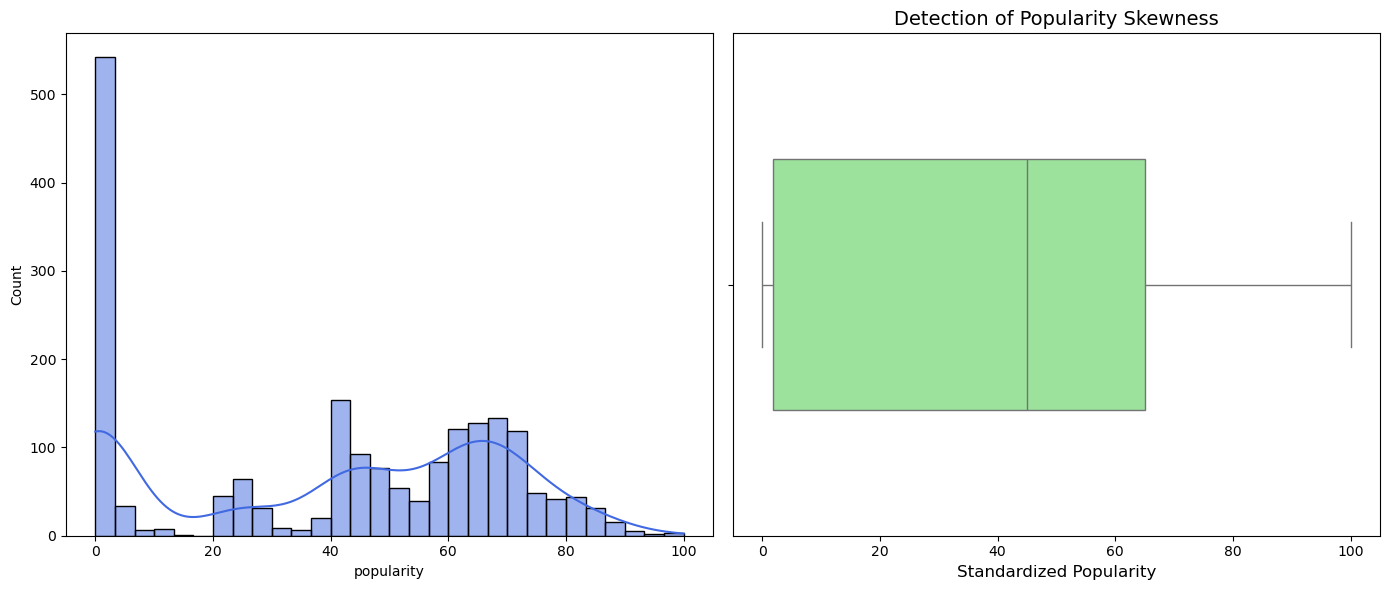

--- DATASET CLEANING SUMMARY ---
Original Song Count: 2000
Filtered Song Count: 1538
Total Songs Removed: 462 (0 Popularity Songs)
New Mean Popularity: 50.7269 (Was 0.00)
---------------------------------


In [10]:
import seaborn as sns
# 1. Load the original transformed dataset
dfexample = pd.read_csv('tracks2026.csv')

# 2. Visualize the Problem: The "Long Tail" of Low Popularity
plt.figure(figsize=(14, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(dfexample['popularity'], kde=True, color='royalblue', bins=30)

# Boxplot to show spread and density
plt.subplot(1, 2, 2)
sns.boxplot(x=dfexample['popularity'], color='lightgreen', width=0.5)
plt.title('Detection of Popularity Skewness', fontsize=14)
plt.xlabel('Standardized Popularity', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Create a filtered DataFrame (Removing the bottom 25%)
df_filtered = dfexample[dfexample['popularity'] > 0]

# 4. Impact Summary for the team
print("--- DATASET CLEANING SUMMARY ---")
print(f"Original Song Count: {len(dfexample)}")
print(f"Filtered Song Count: {len(df_filtered)}")
print(f"Total Songs Removed: {len(dfexample) - len(df_filtered)} (0 Popularity Songs)")
print(f"New Mean Popularity: {df_filtered['popularity'].mean():.4f} (Was 0.00)")
print("---------------------------------")

## Linear regression model with zeros taken out

In [11]:
# Load the transformed dataset
# Perform the same cleaning steps with the new justified set as well
df = pd.read_csv('tracks2026.csv')
df = df.drop(columns = ["track_id"])
df = df.dropna()

# Define features (X) and target (y)
target = 'popularity'
X = df.drop(columns=[target])
y = df[target]

In [12]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = X.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]
# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
# Scale key and time_signature columns, as they have different scale than others
key_timesignature_cols = ["key", "time_signature"]
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
minmax_pipeline = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', MinMaxScaler())
])
# Do OneHotEncoding here to avoid test set containing information about the track-genre categories in training set. 
# If unknown value, ignore
onehotencode_pipeline = Pipeline(steps = [
    ("onehotencode", OneHotEncoder(handle_unknown='ignore'))
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
        ("onehotencode", onehotencode_pipeline, ["track_genre"] )
    ],
    remainder='passthrough'
)
print(no_outlier_cols)
print(outlier_cols_neg)
print(outlier_cols_pos)
print(key_timesignature_cols)



['valence', 'acousticness']
['loudness']
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
['key', 'time_signature']


In [13]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

# Setting a CV score
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

# Scoring variable
scoring = {
    "neg_MSE": "neg_mean_squared_error",
    "neg_RMSE": "neg_root_mean_squared_error",
    "neg_MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Taking out zeros from the training set, but not the test set, to avoid data leakage
X_train_filtered = X_train[y_train > 0]
y_train_filtered = y_train[y_train > 0]

# Linear Regression Pipeline
pipe0 = Pipeline(steps = [('preprocess', preprocess_pipeline),
                         ('reduce_dim', PCA(iterated_power=7)),
                        ('regressor', LinearRegression())
                         ]
                         )


In [18]:
from sklearn.model_selection import GridSearchCV


lr_search = GridSearchCV(
    pipe0, 
    param_grid,
    scoring=scoring,    
    n_jobs=-1,
    cv=cv10,
    refit="R2",
    return_train_score=False)
# Initialize and train the Linear Regression model
lr_search.fit(X_train_filtered, y_train_filtered)

print(f"Best parameters: {lr_search.best_params_}")

# Evaluating on unfileterd test data
y_pred = lr_search.predict(X_test)
r2_realistic = r2_score(y_test, y_pred)
print("R2 Score on Unfiltered Test Set (Realistic Evaluation): ", r2_realistic)

Best parameters: {'reduce_dim': RFE(estimator=SVR(gamma='auto', kernel='linear')), 'reduce_dim__n_features_to_select': 19, 'regressor__fit_intercept': True}
R2 Score on Unfiltered Test Set (Realistic Evaluation):  -0.1989046067208855


Looks like we could very slightly improve the R2 score through this approach

In [15]:
# # 8. Inspect Feature Importance (Coefficients)
# coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
# coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
# print("\n--- Feature Coefficients (Influence on Popularity) ---")
# print(coefficients)

## Comparison of two models

Here I am comparing the two models side by side, to showcase the difference in MSE, MAE, and R2 score

In [19]:
print("R2 Score with no removal of 0 Popularity Songs: ", lr_search0.best_score_)
print("R2 Score with Justified Removal of 0 Popularity Songs (Unrealistic): ", lr_search.best_score_)
print("R2 Score on Unfiltered Test Set (Realistic): ", r2_realistic)

R2 Score with no removal of 0 Popularity Songs:  0.013889304398040415
R2 Score with Justified Removal of 0 Popularity Songs (Unrealistic):  0.09079475070822816
R2 Score on Unfiltered Test Set (Realistic):  -0.1989046067208855


We can see that once we remove the zeros we are able to get a slightly better R2 score on the practice data without zeros, but we end up doing much worse on the test set that includes zeros.

## Conclusion
Working on this linear regression model was a two step process, the first attempt and then a later attempt after getting usatisfactory results witht he first attempt.
We were able to recognize an issue with the model with the amount of zeros that were in the popularity metric. This made it very difficult to get an accurate linear regression model because of how biased the model is, so we came to the decision to remove the zeros from the model.

When we did that we were able to achieve a slightly R2 score on the data without zeros but a worse R2 score on the test score that included zeros.

Overall though this data set is very hard to fit to a highly biased regression model such as linear regression, as the popularity of songs is dependent on much more than just the characteristics of a song.